# Pipeline

Se incluye:

1. **Clasificación** para predecir `compatible`
2. **Regresión** para predecir `relationship_longevity_months`

## 0. Imports y configuración

In [2]:
# =========================
# 0. IMPORTS Y CONFIGURACIÓN
# =========================

# Manejo de datos
import pandas as pd
import numpy as np

# Modelado y validación
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

# Preprocesado y pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.inspection import permutation_importance

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Visualización opcional
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


## 1. Carga de datos

In [ ]:
# =========================
# 1. CARGA DE DATOS
# =========================

df = pd.read_csv("/cupid_algorithm_dataset.csv")

print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (100000, 30)


,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


## 2. Inspección inicial

In [4]:
# =========================
# 2. INSPECCIÓN INICIAL
# =========================

# Información general del dataset
df.info()

# Valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Resumen estadístico de variables numéricas
print("\nResumen estadístico:")
display(df.describe())

# Distribución de la variable objetivo de clasificación
print("\nDistribución de 'compatible':")
print(df["compatible"].value_counts())
print(df["compatible"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  object 
 4   a_career_field                 100000 non-null  object 
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontaneity                  100000 non-null  float64
 12  a_love_language                

,pair_id,a_age,a_education,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,...,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,36.558140,2.951980,0.496463,0.499959,0.500131,0.501397,0.498643,0.499697,0.500012,...,0.499897,0.499177,0.500100,0.500063,0.500779,0.500324,0.500310,63.122273,0.428810,68.906250
std,28867.657797,10.951788,1.117733,0.174898,0.223607,0.224783,0.223860,0.223444,0.224779,0.226265,...,0.223567,0.223989,0.223253,0.223312,0.224214,0.226398,0.225954,10.705780,0.494909,21.334574
min,1.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.500000,0.000000,0.000000
25%,25000.750000,27.000000,2.000000,0.370000,0.330000,0.330000,0.330000,0.320000,0.330000,0.330000,...,0.330000,0.330000,0.330000,0.330000,0.330000,0.320000,0.330000,55.900000,0.000000,54.000000
50%,50000.500000,37.000000,3.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,...,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,63.000000,0.000000,69.000000
75%,75000.250000,46.000000,4.000000,0.620000,0.670000,0.670000,0.680000,0.670000,0.670000,0.670000,...,0.670000,0.670000,0.670000,0.670000,0.680000,0.680000,0.670000,70.300000,1.000000,83.000000
max,100000.000000,55.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,120.000000



Distribución de 'compatible':
compatible
0    57119
1    42881
Name: count, dtype: int64
compatible
0    0.57119
1    0.42881
Name: proportion, dtype: float64


## 2.1 Feature engineering orientado a la relación entre perfiles

A partir del análisis exploratorio del Hito 2, se construyen variables derivadas que representan **similitud, distancia y coincidencia** entre ambos perfiles. Esto permite que los modelos trabajen sobre la relación entre Persona A y Persona B, en lugar de tratar ambas descripciones como bloques independientes.

In [5]:
# =========================
# 2.1 FEATURE ENGINEERING
# Basado en relaciones entre Persona A y Persona B
# =========================

df_fe = df.copy()

# -------------------------
# Variables relacionales numéricas
# -------------------------
df_fe["age_gap"] = np.abs(df_fe["a_age"] - df_fe["b_age"])
df_fe["education_diff"] = np.abs(df_fe["a_education"] - df_fe["b_education"])
df_fe["ambition_diff"] = np.abs(df_fe["a_career_ambition"] - df_fe["b_career_ambition"])
df_fe["spontaneity_diff"] = np.abs(df_fe["a_spontaneity"] - df_fe["b_spontaneity"])
df_fe["emotional_expressiveness_diff"] = np.abs(
    df_fe["a_emotional_expressiveness"] - df_fe["b_emotional_expressiveness"]
)

personality_traits = ["openness", "extraversion", "agreeableness", "conscientiousness"]
for trait in personality_traits:
    df_fe[f"{trait}_diff"] = np.abs(df_fe[f"a_{trait}"] - df_fe[f"b_{trait}"])

df_fe["personality_distance_mean"] = df_fe[[f"{t}_diff" for t in personality_traits]].mean(axis=1)
df_fe["personality_distance_sum"] = df_fe[[f"{t}_diff" for t in personality_traits]].sum(axis=1)

# -------------------------
# Variables de coincidencia
# -------------------------
df_fe["same_location"] = (df_fe["a_location"] == df_fe["b_location"]).astype(int)
df_fe["same_career_field"] = (df_fe["a_career_field"] == df_fe["b_career_field"]).astype(int)
df_fe["same_chronotype"] = (df_fe["a_chronotype"] == df_fe["b_chronotype"]).astype(int)
df_fe["same_love_language"] = (df_fe["a_love_language"] == df_fe["b_love_language"]).astype(int)

# -------------------------
# Variables por rangos / umbrales
# -------------------------
df_fe["age_gap_small"] = (df_fe["age_gap"] <= 5).astype(int)
df_fe["age_gap_medium"] = ((df_fe["age_gap"] > 5) & (df_fe["age_gap"] <= 10)).astype(int)
df_fe["age_gap_large"] = (df_fe["age_gap"] > 10).astype(int)
df_fe["very_large_age_gap"] = (df_fe["age_gap"] > 15).astype(int)

df_fe["high_personality_similarity"] = (df_fe["personality_distance_mean"] < 0.20).astype(int)
df_fe["similar_ambition"] = (df_fe["ambition_diff"] < 0.20).astype(int)

# -------------------------
# Interacciones / score agregado
# -------------------------
df_fe["same_location_and_love_language"] = (
    df_fe["same_location"] * df_fe["same_love_language"]
)

df_fe["overall_match_score"] = (
    (1 - df_fe["personality_distance_mean"]) * 0.45 +
    (1 - df_fe["ambition_diff"]) * 0.25 +
    df_fe["same_location"] * 0.10 +
    df_fe["same_love_language"] * 0.10 +
    (1 - np.clip(df_fe["age_gap"] / 20, 0, 1)) * 0.10
)

# -------------------------
# Conjunto final de features modelables
# -------------------------
engineered_feature_cols = [
    "age_gap", "education_diff", "ambition_diff", "spontaneity_diff",
    "emotional_expressiveness_diff",
    "openness_diff", "extraversion_diff", "agreeableness_diff", "conscientiousness_diff",
    "personality_distance_mean", "personality_distance_sum",
    "same_location", "same_career_field", "same_chronotype", "same_love_language",
    "age_gap_small", "age_gap_medium", "age_gap_large", "very_large_age_gap",
    "high_personality_similarity", "similar_ambition",
    "same_location_and_love_language", "overall_match_score"
]

print(f"Número de variables de feature engineering: {len(engineered_feature_cols)}")
display(df_fe[engineered_feature_cols + ['compatible', 'relationship_longevity_months']].head())

Número de variables de feature engineering: 23


,age_gap,education_diff,ambition_diff,spontaneity_diff,emotional_expressiveness_diff,openness_diff,extraversion_diff,agreeableness_diff,conscientiousness_diff,personality_distance_mean,...,age_gap_small,age_gap_medium,age_gap_large,very_large_age_gap,high_personality_similarity,similar_ambition,same_location_and_love_language,overall_match_score,compatible,relationship_longevity_months
0,26,0,0.54,0.19,0.14,0.32,0.17,0.35,0.01,0.2125,...,0,0,1,1,0,0,0,0.469375,0,60
1,6,1,0.14,0.16,0.11,0.07,0.39,0.31,0.14,0.2275,...,0,1,0,0,0,1,0,0.632625,0,59
2,21,2,0.02,0.17,0.21,0.05,0.57,0.15,0.39,0.2900,...,0,0,1,1,0,1,0,0.664500,1,84
3,18,2,0.15,0.25,0.06,0.13,0.07,0.26,0.60,0.2650,...,0,0,1,1,0,1,0,0.553250,0,70
4,14,1,0.07,0.27,0.06,0.09,0.04,0.18,0.30,0.1525,...,0,0,1,0,1,1,0,0.743875,1,68


## 3. Bloque 1 — Clasificación de `compatible`

En este bloque:
- separamos `X` e `y`,
- hacemos train/validation/test split estratificado,
- seleccionamos variables con `mutual_info_classif`,
- ajustamos una **Logistic Regression** con GridSearch,
- y la comparamos contra **Random Forest**.


In [6]:

# =========================
# 3. CLASIFICACIÓN: PREDECIR 'compatible'
# Split 70% train / 15% validation / 15% test
# =========================

# Variables predictoras y target
X_clf = df_fe[engineered_feature_cols].copy()
y_clf = df_fe["compatible"]

# One-hot encoding sobre variables categóricas derivadas
X_clf = pd.get_dummies(X_clf, drop_first=True)

# 70% train / 30% temporal
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# 15% validation / 15% test
X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf,
    y_temp_clf,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp_clf
)

print("Shapes clasificación:")
print("Train:", X_train_clf.shape, y_train_clf.shape)
print("Validation:", X_val_clf.shape, y_val_clf.shape)
print("Test:", X_test_clf.shape, y_test_clf.shape)
print("\nDistribución train:")
print(y_train_clf.value_counts(normalize=True))


Shapes clasificación:
Train: (70000, 23) (70000,)
Validation: (15000, 23) (15000,)
Test: (15000, 23) (15000,)

Distribución train:
compatible
0    0.571186
1    0.428814
Name: proportion, dtype: float64


In [7]:
# =========================
# 3.1 FEATURE SELECTION PARA CLASIFICACIÓN
# (solo usando train para evitar leakage)
# =========================

mi_clf = mutual_info_classif(
    X_train_clf,
    y_train_clf,
    random_state=RANDOM_STATE
)

mi_clf_series = pd.Series(mi_clf, index=X_train_clf.columns).sort_values(ascending=False)

print("Top 15 features por mutual information:")
display(mi_clf_series.head(15))

threshold_clf = 0.001
selected_features_clf = mi_clf_series[mi_clf_series > threshold_clf].index.tolist()

if len(selected_features_clf) == 0:
    selected_features_clf = mi_clf_series.head(20).index.tolist()

print(f"Número de features seleccionadas para clasificación: {len(selected_features_clf)}")
print(selected_features_clf)

X_train_clf_sel = X_train_clf[selected_features_clf]
X_val_clf_sel = X_val_clf[selected_features_clf]
X_test_clf_sel = X_test_clf[selected_features_clf]


Top 15 features por mutual information:


,0
overall_match_score,0.064956
same_love_language,0.050687
ambition_diff,0.026906
similar_ambition,0.025704
emotional_expressiveness_diff,0.024648
same_location_and_love_language,0.019650
personality_distance_sum,0.017656
personality_distance_mean,0.014726
high_personality_similarity,0.010161
spontaneity_diff,0.009406


Número de features seleccionadas para clasificación: 20
['overall_match_score', 'same_love_language', 'ambition_diff', 'similar_ambition', 'emotional_expressiveness_diff', 'same_location_and_love_language', 'personality_distance_sum', 'personality_distance_mean', 'high_personality_similarity', 'spontaneity_diff', 'age_gap_large', 'very_large_age_gap', 'same_career_field', 'same_location', 'age_gap_small', 'age_gap', 'education_diff', 'extraversion_diff', 'agreeableness_diff', 'openness_diff']


In [8]:

# =========================
# 3.2 DEFINICIÓN DE LOS 5 MODELOS DE CLASIFICACIÓN
# =========================

classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            C=1.0,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE
        ))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=25, weights="distance"))
    ])
}

def evaluate_classification(model, X, y_true, dataset_name, model_name):
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
        roc_auc = roc_auc_score(y_true, y_prob)
    else:
        roc_auc = np.nan

    return {
        "Modelo": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc
    }


In [9]:
# =========================
# 3.3 ENTRENAMIENTO Y EVALUACIÓN EN VALIDATION
# =========================

classification_results = []
trained_classification_models = {}

for model_name, model in classification_models.items():
    model.fit(X_train_clf_sel, y_train_clf)
    trained_classification_models[model_name] = model

    val_metrics = evaluate_classification(
        model,
        X_val_clf_sel,
        y_val_clf,
        dataset_name="Validation",
        model_name=model_name
    )
    classification_results.append(val_metrics)

results_clf_val = pd.DataFrame(classification_results).sort_values(
    by=["F1", "ROC-AUC"], ascending=False
).reset_index(drop=True)

print("===== RESULTADOS EN VALIDATION (Clasificación) =====")
display(results_clf_val)


===== RESULTADOS EN VALIDATION (Clasificación) =====


,Modelo,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Validation,0.705333,0.644044,0.699316,0.670543,0.783819
1,Random Forest,Validation,0.710667,0.657530,0.678794,0.667993,0.780666
2,Decision Tree,Validation,0.690200,0.625404,0.692009,0.657023,0.761423
3,Gradient Boosting,Validation,0.715067,0.689831,0.609608,0.647243,0.784109
4,KNN,Validation,0.701533,0.666157,0.609297,0.636460,0.759690


In [10]:
# =========================
# 3.4 SELECCIÓN DEL MEJOR MODELO Y EVALUACIÓN FINAL EN TEST
# =========================

best_clf_name = results_clf_val.iloc[0]["Modelo"]
best_clf_model = trained_classification_models[best_clf_name]

print(f"Mejor modelo de clasificación según Validation: {best_clf_name}")

test_metrics_best_clf = evaluate_classification(
    best_clf_model,
    X_test_clf_sel,
    y_test_clf,
    dataset_name="Test",
    model_name=best_clf_name
)

results_clf_test = pd.DataFrame([test_metrics_best_clf])

print("\n===== RESULTADO FINAL EN TEST (Clasificación) =====")
display(results_clf_test)

y_pred_best_clf = best_clf_model.predict(X_test_clf_sel)

print("\nClassification report:")
print(classification_report(y_test_clf, y_pred_best_clf))

print("\nConfusion matrix:")
print(confusion_matrix(y_test_clf, y_pred_best_clf))


Mejor modelo de clasificación según Validation: Logistic Regression

===== RESULTADO FINAL EN TEST (Clasificación) =====


,Modelo,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Test,0.7182,0.659945,0.707245,0.682777,0.791749



Classification report:
              precision    recall  f1-score   support

           0       0.77      0.73      0.75      8568
           1       0.66      0.71      0.68      6432

    accuracy                           0.72     15000
   macro avg       0.71      0.72      0.71     15000
weighted avg       0.72      0.72      0.72     15000


Confusion matrix:
[[6224 2344]
 [1883 4549]]


In [11]:
# =========================
# 3.5 COMPARATIVA GLOBAL CLASIFICACIÓN (Validation + Test)
# =========================

results_clf_all = pd.concat([results_clf_val, results_clf_test], ignore_index=True)
display(results_clf_all.sort_values(by=["Dataset", "F1"], ascending=[True, False]))


,Modelo,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
5,Logistic Regression,Test,0.718200,0.659945,0.707245,0.682777,0.791749
0,Logistic Regression,Validation,0.705333,0.644044,0.699316,0.670543,0.783819
1,Random Forest,Validation,0.710667,0.657530,0.678794,0.667993,0.780666
2,Decision Tree,Validation,0.690200,0.625404,0.692009,0.657023,0.761423
3,Gradient Boosting,Validation,0.715067,0.689831,0.609608,0.647243,0.784109
4,KNN,Validation,0.701533,0.666157,0.609297,0.636460,0.759690


In [12]:
# =========================
# 3.6 INTERPRETABILIDAD DEL MEJOR MODELO DE CLASIFICACIÓN
# =========================

if best_clf_name == "Logistic Regression":
    coef_clf = pd.DataFrame({
        "feature": selected_features_clf,
        "coef": best_clf_model.named_steps["model"].coef_[0]
    }).sort_values(by="coef", key=abs, ascending=False)

    print("Top 15 coeficientes absolutos de Logistic Regression:")
    display(coef_clf.head(15))

elif best_clf_name in ["Random Forest", "Gradient Boosting", "Decision Tree"]:
    importance_clf = pd.DataFrame({
        "feature": selected_features_clf,
        "importance": best_clf_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print(f"Top 15 importancias de {best_clf_name}:")
    display(importance_clf.head(15))

else:
    print(f"El modelo seleccionado ({best_clf_name}) no dispone de importancias o coeficientes directos fácilmente interpretables.")


Top 15 coeficientes absolutos de Logistic Regression:


,feature,coef
1,same_love_language,0.611900
4,emotional_expressiveness_diff,-0.563530
2,ambition_diff,-0.439404
0,overall_match_score,0.426603
9,spontaneity_diff,-0.371039
12,same_career_field,0.205232
19,openness_diff,-0.103336
17,extraversion_diff,-0.088654
13,same_location,-0.087879
7,personality_distance_mean,-0.067114


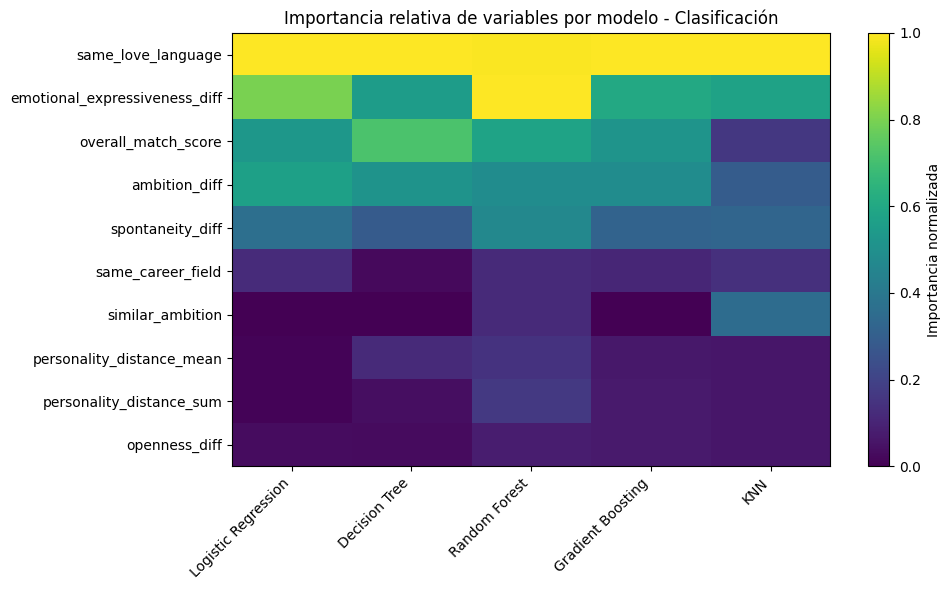

,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting,KNN
same_love_language,0.049357,0.061134,0.038934,0.067062,0.052301
emotional_expressiveness_diff,0.039355,0.033687,0.039220,0.040521,0.030202
overall_match_score,0.026127,0.043782,0.022770,0.034657,0.008495
ambition_diff,0.028014,0.031382,0.019097,0.032712,0.015217
spontaneity_diff,0.018009,0.017459,0.018247,0.021410,0.017016
same_career_field,0.006009,0.001455,0.004724,0.007314,0.007274
similar_ambition,0.000163,0.000000,0.004659,0.000000,0.018459
personality_distance_mean,0.000572,0.007278,0.005703,0.004228,0.003154
personality_distance_sum,0.000572,0.002187,0.006563,0.004751,0.003154
openness_diff,0.001684,0.001712,0.003195,0.004973,0.003143


In [14]:
# =========================
# 3.7 IMPORTANCIA DE VARIABLES - CLASIFICACIÓN
# =========================

perm_importances_clf = {}

for name, model in classification_models.items():
    result = permutation_importance(
        model,
        X_val_clf_sel,
        y_val_clf,
        n_repeats=10,
        random_state=42,
        scoring="f1"
    )

    importances = pd.Series(result.importances_mean, index=selected_features_clf)
    perm_importances_clf[name] = importances

perm_importances_clf_df = pd.DataFrame(perm_importances_clf).fillna(0)

# Nos quedamos con las 10 variables más relevantes en promedio
top_features_clf = perm_importances_clf_df.mean(axis=1).sort_values(ascending=False).head(10).index
perm_importances_clf_top = perm_importances_clf_df.loc[top_features_clf]

# Normalización por modelo para que sean comparables visualmente
perm_importances_clf_norm = perm_importances_clf_top.copy()
for col in perm_importances_clf_norm.columns:
    max_val = perm_importances_clf_norm[col].abs().max()
    if max_val > 0:
        perm_importances_clf_norm[col] = perm_importances_clf_norm[col] / max_val

# Heatmap simple con matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(perm_importances_clf_norm, aspect="auto")
plt.colorbar(label="Importancia normalizada")
plt.xticks(ticks=np.arange(len(perm_importances_clf_norm.columns)), labels=perm_importances_clf_norm.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(perm_importances_clf_norm.index)), labels=perm_importances_clf_norm.index)
plt.title("Importancia relativa de variables por modelo - Clasificación")
plt.tight_layout()
plt.show()

display(perm_importances_clf_top)

## 4. Bloque 2 — Regresión de `relationship_longevity_months`

En este bloque:
- cambiamos el target a la duración de la relación,
- evitamos leakage eliminando `compatible` y `compatibility_score`,
- usamos una partición **70/15/15**,
- entrenamos **5 modelos distintos de regresión**,
- y comparamos su rendimiento con MAE, RMSE y $R^2$.


In [15]:

# =========================
# 4. REGRESIÓN: PREDECIR 'relationship_longevity_months'
# Split 70% train / 15% validation / 15% test
# =========================

X_reg = df_fe[engineered_feature_cols].copy()
y_reg = df_fe["relationship_longevity_months"]

X_reg = pd.get_dummies(X_reg, drop_first=True)

# Transformación logarítmica para estabilizar la distribución
y_reg_log = np.log1p(y_reg)

# 70% train / 30% temporal
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg,
    y_reg_log,
    test_size=0.30,
    random_state=RANDOM_STATE
)

# 15% validation / 15% test
X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg,
    y_temp_reg,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Shapes regresión:")
print("Train:", X_train_reg.shape, y_train_reg.shape)
print("Validation:", X_val_reg.shape, y_val_reg.shape)
print("Test:", X_test_reg.shape, y_test_reg.shape)


Shapes regresión:
Train: (70000, 23) (70000,)
Validation: (15000, 23) (15000,)
Test: (15000, 23) (15000,)


In [16]:
# =========================
# 4.1 FEATURE SELECTION PARA REGRESIÓN
# (solo usando train para evitar leakage)
# =========================

mi_reg = mutual_info_regression(X_train_reg, y_train_reg, random_state=RANDOM_STATE)

mi_reg_series = pd.Series(mi_reg, index=X_train_reg.columns).sort_values(ascending=False)

print("Top 15 features por mutual information (regresión):")
display(mi_reg_series.head(15))

threshold_reg = 0.001
selected_features_reg = mi_reg_series[mi_reg_series > threshold_reg].index.tolist()

if len(selected_features_reg) == 0:
    selected_features_reg = mi_reg_series.head(20).index.tolist()

print(f"Número de features seleccionadas para regresión: {len(selected_features_reg)}")

X_train_reg_sel = X_train_reg[selected_features_reg]
X_val_reg_sel = X_val_reg[selected_features_reg]
X_test_reg_sel = X_test_reg[selected_features_reg]


Top 15 features por mutual information (regresión):


,0
overall_match_score,0.025674
same_love_language,0.024178
personality_distance_mean,0.011794
personality_distance_sum,0.011032
ambition_diff,0.010671
emotional_expressiveness_diff,0.008853
same_location_and_love_language,0.008723
similar_ambition,0.008610
openness_diff,0.006896
spontaneity_diff,0.005741


Número de features seleccionadas para regresión: 16


In [17]:

# =========================
# 4.2 DEFINICIÓN DE LOS 5 MODELOS DE REGRESIÓN
# =========================

regression_models = {
    "Ridge": Ridge(alpha=1.0),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

def evaluate_regression(model, X, y_true_log, dataset_name, model_name):
    y_pred_log = model.predict(X)

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_true_log)

    return {
        "Modelo": model_name,
        "Dataset": dataset_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


In [18]:
# =========================
# 4.3 ENTRENAMIENTO Y EVALUACIÓN EN VALIDATION
# =========================

regression_results = []
trained_regression_models = {}

for model_name, model in regression_models.items():
    model.fit(X_train_reg_sel, y_train_reg)
    trained_regression_models[model_name] = model

    val_metrics = evaluate_regression(
        model,
        X_val_reg_sel,
        y_val_reg,
        dataset_name="Validation",
        model_name=model_name
    )
    regression_results.append(val_metrics)

results_reg_val = pd.DataFrame(regression_results).sort_values(
    by=["MAE", "RMSE"], ascending=True
).reset_index(drop=True)

print("===== RESULTADOS EN VALIDATION (Regresión) =====")
display(results_reg_val)


===== RESULTADOS EN VALIDATION (Regresión) =====


,Modelo,Dataset,MAE,RMSE,R2
0,Ridge,Validation,16.438185,20.482438,0.080404
1,Gradient Boosting,Validation,16.448593,20.495582,0.079223
2,Random Forest,Validation,16.510136,20.574771,0.072095
3,Decision Tree,Validation,16.928690,21.134641,0.020908
4,KNN,Validation,18.098933,22.627234,-0.122268


In [19]:
# =========================
# 4.4 SELECCIÓN DEL MEJOR MODELO Y EVALUACIÓN FINAL EN TEST
# =========================

best_reg_name = results_reg_val.iloc[0]["Modelo"]
best_reg_model = trained_regression_models[best_reg_name]

print(f"Mejor modelo de regresión según Validation: {best_reg_name}")

test_metrics_best_reg = evaluate_regression(
    best_reg_model,
    X_test_reg_sel,
    y_test_reg,
    dataset_name="Test",
    model_name=best_reg_name
)

results_reg_test = pd.DataFrame([test_metrics_best_reg])

print("\n===== RESULTADO FINAL EN TEST (Regresión) =====")
display(results_reg_test)


Mejor modelo de regresión según Validation: Ridge

===== RESULTADO FINAL EN TEST (Regresión) =====


,Modelo,Dataset,MAE,RMSE,R2
0,Ridge,Test,16.271024,20.333607,0.075771


In [20]:
# =========================
# 4.5 COMPARATIVA GLOBAL REGRESIÓN (Validation + Test)
# =========================

results_reg_all = pd.concat([results_reg_val, results_reg_test], ignore_index=True)
display(results_reg_all.sort_values(by=["Dataset", "MAE"], ascending=[True, True]))


,Modelo,Dataset,MAE,RMSE,R2
5,Ridge,Test,16.271024,20.333607,0.075771
0,Ridge,Validation,16.438185,20.482438,0.080404
1,Gradient Boosting,Validation,16.448593,20.495582,0.079223
2,Random Forest,Validation,16.510136,20.574771,0.072095
3,Decision Tree,Validation,16.928690,21.134641,0.020908
4,KNN,Validation,18.098933,22.627234,-0.122268


In [21]:
# =========================
# 4.6 INTERPRETABILIDAD DEL MEJOR MODELO DE REGRESIÓN
# =========================

if best_reg_name in ["Linear Regression", "Ridge"]:
    coef_reg = pd.DataFrame({
        "feature": selected_features_reg,
        "coef": best_reg_model.coef_
    }).sort_values(by="coef", key=abs, ascending=False)

    print(f"Top 15 coeficientes absolutos de {best_reg_name}:")
    display(coef_reg.head(15))

elif best_reg_name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
    importance_reg = pd.DataFrame({
        "feature": selected_features_reg,
        "importance": best_reg_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print(f"Top 15 importancias de {best_reg_name}:")
    display(importance_reg.head(15))

else:
    print(f"El modelo seleccionado ({best_reg_name}) no dispone de importancias o coeficientes directos fácilmente interpretables.")


Top 15 coeficientes absolutos de Ridge:


,feature,coef
4,ambition_diff,-0.298908
0,overall_match_score,0.281243
5,emotional_expressiveness_diff,-0.271856
9,spontaneity_diff,-0.186556
1,same_love_language,0.144401
3,personality_distance_sum,-0.067902
13,same_chronotype,0.039274
8,openness_diff,-0.033855
2,personality_distance_mean,-0.016976
10,conscientiousness_diff,0.014456


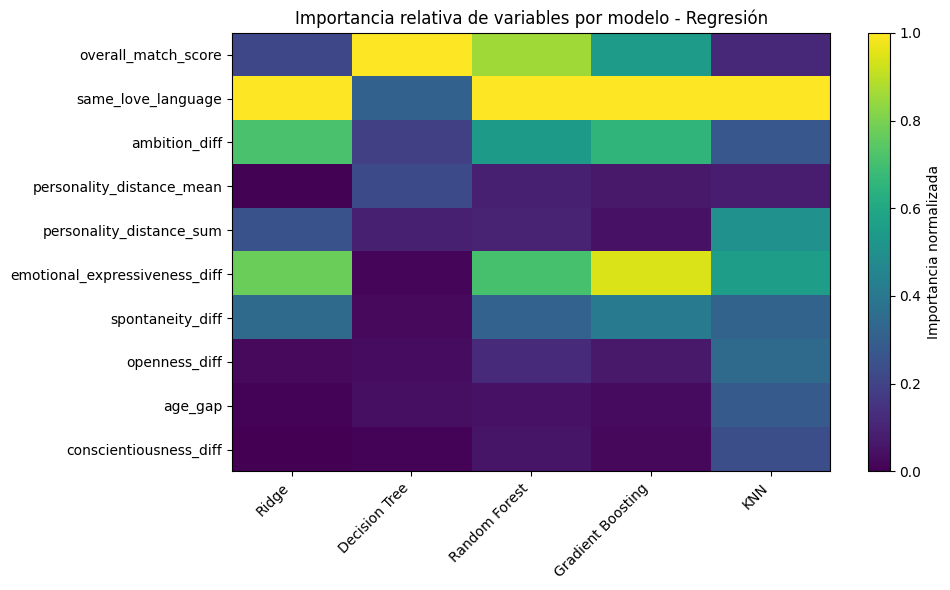

,Ridge,Decision Tree,Random Forest,Gradient Boosting,KNN
overall_match_score,0.001336,0.191743,0.005701,0.002771,0.000785
same_love_language,0.006194,0.059805,0.006661,0.005031,0.007192
ambition_diff,0.004419,0.036171,0.003634,0.003291,0.001939
personality_distance_mean,0.000025,0.043066,0.000588,0.000350,0.000559
personality_distance_sum,0.001555,0.016952,0.000631,0.000237,0.003625
emotional_expressiveness_diff,0.004799,0.003572,0.004714,0.004752,0.004005
spontaneity_diff,0.002137,0.004730,0.002100,0.002095,0.002299
openness_diff,0.000163,0.006562,0.000815,0.000351,0.002472
age_gap,0.000064,0.007550,0.000324,0.000139,0.002030
conscientiousness_diff,-0.000003,0.001444,0.000387,0.000101,0.001730


In [22]:
# =========================
# 4.7 IMPORTANCIA DE VARIABLES - REGRESIÓN
# =========================

perm_importances_reg = {}

for name, model in regression_models.items():
    result = permutation_importance(
        model,
        X_val_reg_sel,
        y_val_reg,
        n_repeats=10,
        random_state=42,
        scoring="neg_mean_squared_error"
    )

    importances = pd.Series(result.importances_mean, index=selected_features_reg)
    perm_importances_reg[name] = importances

perm_importances_reg_df = pd.DataFrame(perm_importances_reg).fillna(0)

# Top variables en promedio
top_features_reg = perm_importances_reg_df.mean(axis=1).sort_values(ascending=False).head(10).index
perm_importances_reg_top = perm_importances_reg_df.loc[top_features_reg]

# Normalización por modelo
perm_importances_reg_norm = perm_importances_reg_top.copy()
for col in perm_importances_reg_norm.columns:
    max_val = perm_importances_reg_norm[col].abs().max()
    if max_val > 0:
        perm_importances_reg_norm[col] = perm_importances_reg_norm[col] / max_val

plt.figure(figsize=(10, 6))
plt.imshow(perm_importances_reg_norm, aspect="auto")
plt.colorbar(label="Importancia normalizada")
plt.xticks(ticks=np.arange(len(perm_importances_reg_norm.columns)), labels=perm_importances_reg_norm.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(perm_importances_reg_norm.index)), labels=perm_importances_reg_norm.index)
plt.title("Importancia relativa de variables por modelo - Regresión")
plt.tight_layout()
plt.show()

display(perm_importances_reg_top)

## 5. Conclusiones

### Sobre clasificación (`compatible`)
Tras comparar cinco modelos distintos sobre una partición 70/15/15, se seleccionará como mejor
modelo aquel que obtenga el mejor equilibrio entre **F1-score** y **ROC-AUC** en el conjunto de
validación. La evaluación final en test permitirá confirmar si dicho modelo mantiene su capacidad de
generalización sobre datos no vistos.

Finalmente el modelo con mejor comportamiento fue Logistic Regression, que obtuvo el mayor F1-score en validación y mantuvo un rendimiento estable en test. Esto sugiere que, tras el proceso de ingeniería de características, la relación entre las variables derivadas y la compatibilidad puede modelarse adecuadamente mediante una frontera relativamente simple e interpretable.

Además del rendimiento predictivo, conviene interpretar el resultado desde una perspectiva de dominio:
si los modelos basados en árboles superan a los lineales, ello sugerirá la existencia de relaciones no
lineales entre variables demográficas, profesionales y de personalidad; si, por el contrario, los modelos
lineales compiten bien, podría concluirse que la señal del problema es más simple y estable.

### Sobre regresión (`relationship_longevity_months`)
En el problema de regresión, el mejor modelo será el que consiga el menor **MAE** y **RMSE** en
validación, manteniendo además un valor de **R²** lo más alto posible en el conjunto de test. Esta
comparación permitirá valorar hasta qué punto la duración de una relación puede explicarse a partir
de las variables disponibles en el dataset.

Aquí los resultados fueron sensiblemente más modestos. El mejor modelo fue Ridge, pero con un valor de **R²** bajo, lo que indica que las variables disponibles explican solo una parte limitada de la variabilidad de la duración de la relación. Esto sugiere que la longevidad depende de factores adicionales no presentes en el dataset o de relaciones más complejas difíciles de capturar con los modelos evaluados.


## 6. Mejoras

- Ajustar hiperparámetros de los cinco modelos mediante búsqueda más exhaustiva.
- Probar nuevos métodos de selección de variables.
- Construir variables derivadas más ricas (distancias, interacciones y similitudes).
- Explorar modelos multi-output en una iteración futura.
- Incorporar técnicas avanzadas de explicabilidad como SHAP o LIME.


1. Eliminar pair_id
2. Ajustar class imbalance:
class_weight='balanced'
3.Probar XGBoost / LightGBM